## 决策树：
决策树（decision tree）是一个树结构（可以是二叉树或非二叉树）。其每个非叶节点表示一个特征属性上的测试，每个分支代表这个特征属性在某个值域上的输出，而每个叶节点存放一个类别。使用决策树进行决策的过程就是从根节点开始，测试待分类项中相应的特征属性，并按照其值选择输出分支，直到到达叶子节点，将叶子节点存放的类别作为决策结果。


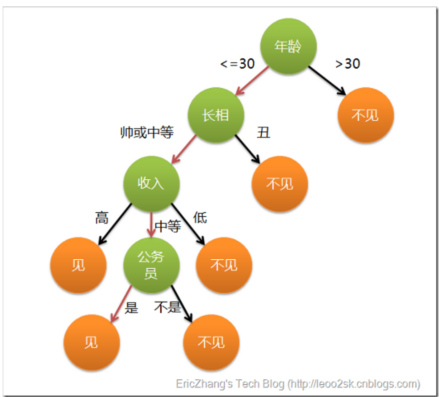




## 构建树的原则

我们构建一棵决策树的基本想法就是，我们希望决策树每个叶子节点包含的样本尽可能属于同一个类别，**即结点的“纯度”越来越高**

## 决策树划分选择的方法

根据构建树的原则来看，即使得每个结点的纯度尽可能小，那么我们需要一些指标评价“纯度”这个概念。信息熵和基尼指数是两个常用的指标。

## 决策树算法
### 1、熵(Entropy)
信息熵(information entropy)是度量样本集合纯度的常用指标；

在信息论与概率统计中，熵是表示随机变量不确定性的度，熵越大，随机变量的不确定性就越大，反之则不确定性越小；

假定当前样本集合D中第k类样本所占的比例为 pk(k=1,2,…,|Y|) ,则D的信息熵为:
$$ Ent(D) = -\sum_{k=1}^{|Y|} p_k log_2p_k $$

Ent(D)的值越小，D的纯度越高(约定：若p=0则plog2p=0)



数据集：
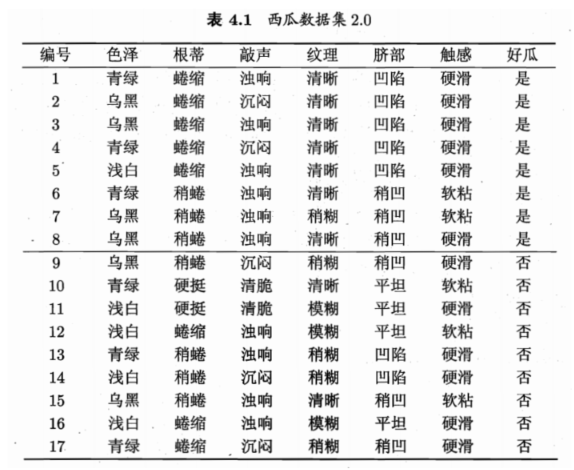

### 2、信息增益(Information Gain)
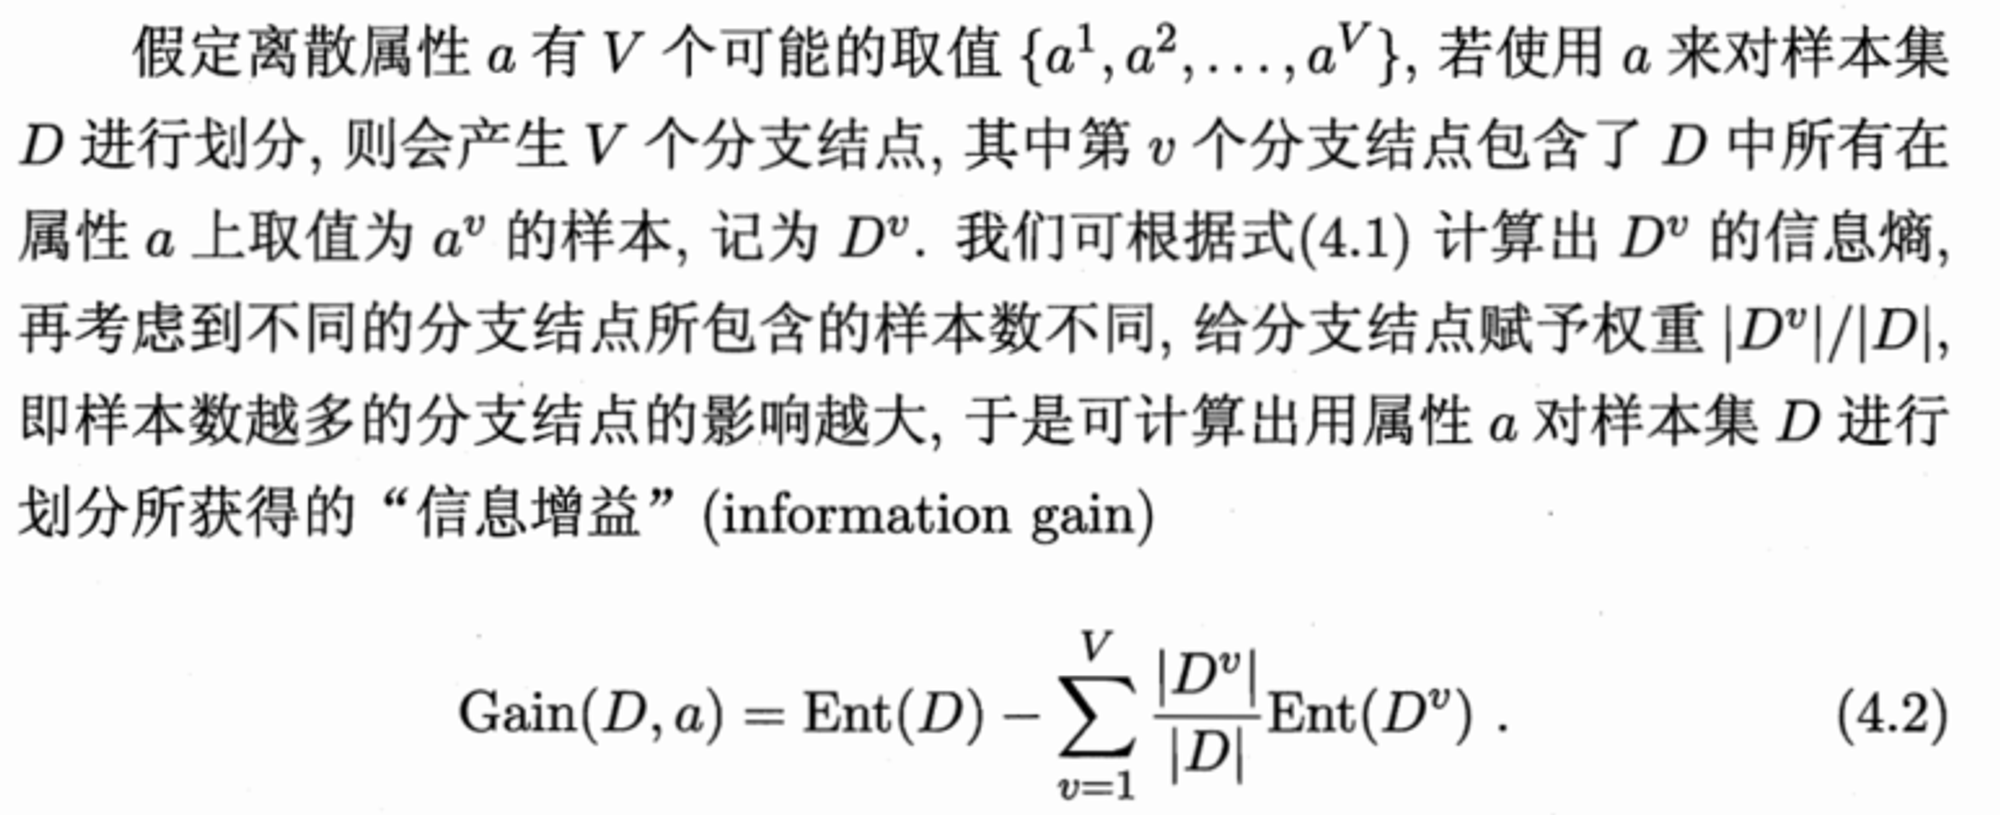

一般而言，信息增益越大，则意味着用属性a来进行划分所获得的纯度提升越大：

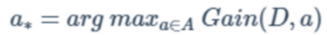

**ID3就是以信息增益为准则来选择划分属性的**

举例：

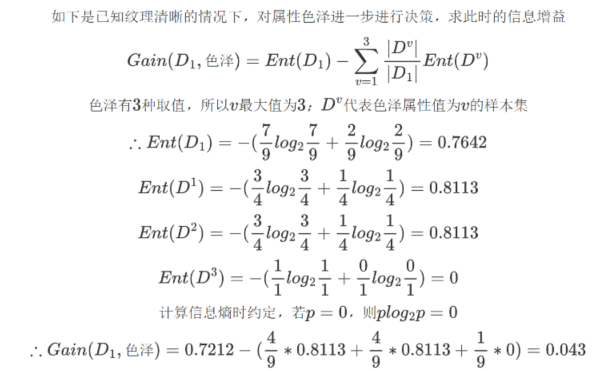


### 3、增益率
实际上，信息增益对可取值数目较多的属性有所偏好(如编号，在西瓜集中若以编号为划分属性，则其信息增益最大)，为减少由于偏好而带来的不利影响，C4.5算法使用增益率(gain ratio)来选择最优划分属性:
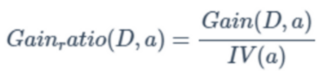


其中：
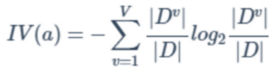

称为属性a的固有值(intrinsic value),属性a的可能数目越多，则IV(a)的值通常越大

- 信息增益率准则对可取值数目较少的属性有所偏好，
- C4.5采用的是先从候选划分属性中寻找出信息增益率最高的属性

举例：
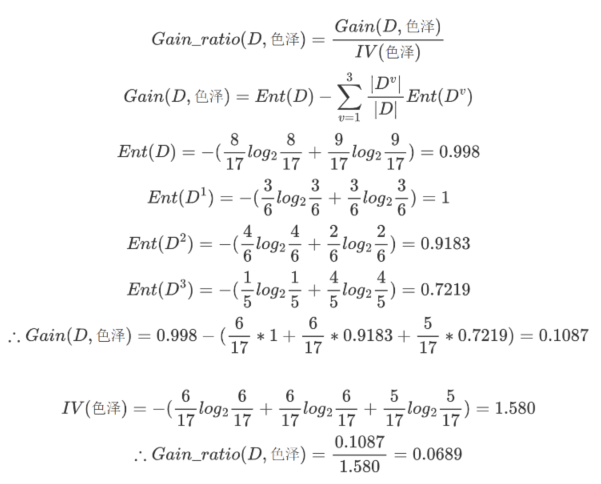

### 4、基尼指数（Gini Index）
CART(Classification and Regression Tree)使用基尼指数(Gini index)来选择划分属性，数据集的纯度可用基尼值来度量
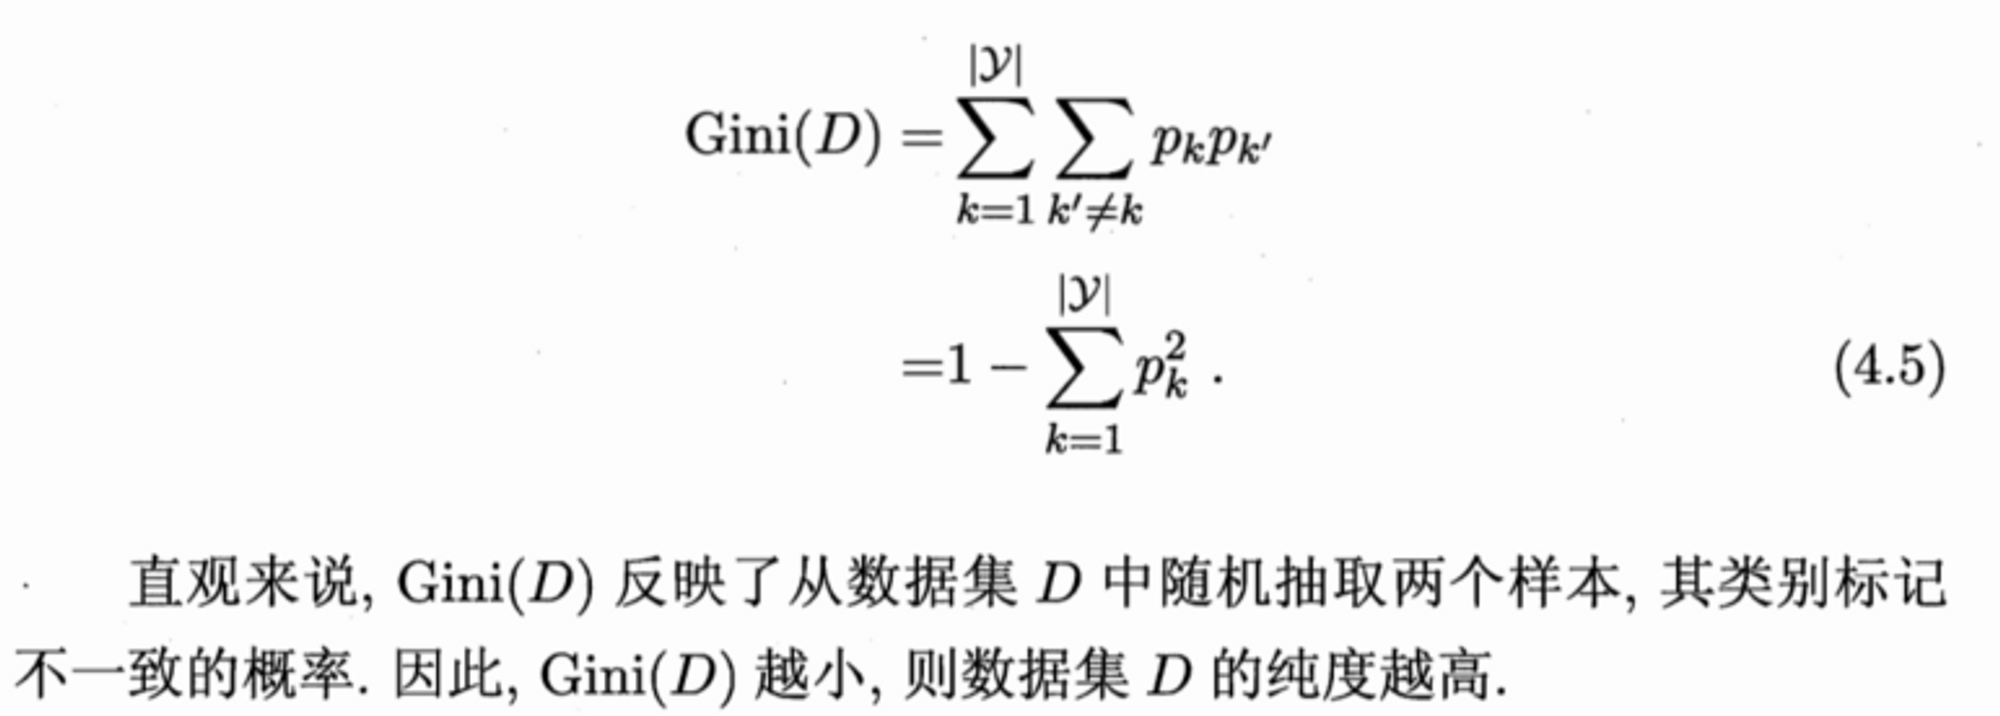
属性a的基尼指数定义为：
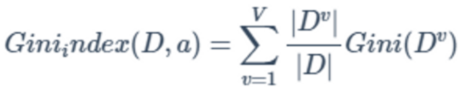


在属性集合A中寻找:
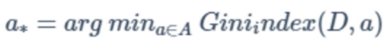

CART决策树使用基尼指数作为属性划分的标准

我们使用色泽属性进行举例，计算此时的基尼指数：
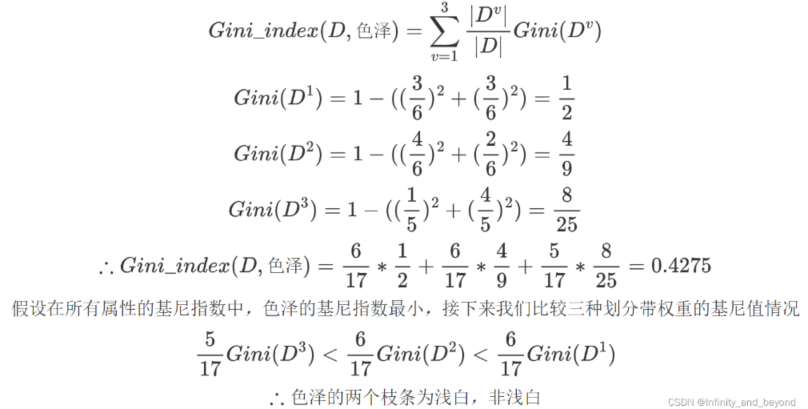

### 5、剪枝处理
剪枝(pruning)是决策树学习算法对付过拟合的主要手段，基本策略有预剪枝(prepruning)和后剪枝(post-pruning)

- 预剪枝：在决策树的生成过程中，对每个节点在划分前先进行估计，若当前节点的划分不能带来泛化性能提升则停止划分
- 后剪枝：先生成一个完整的树，然后自底向上对非叶节点考察，若将该节点对应的子数替换为叶节点能提升泛化性能则替换

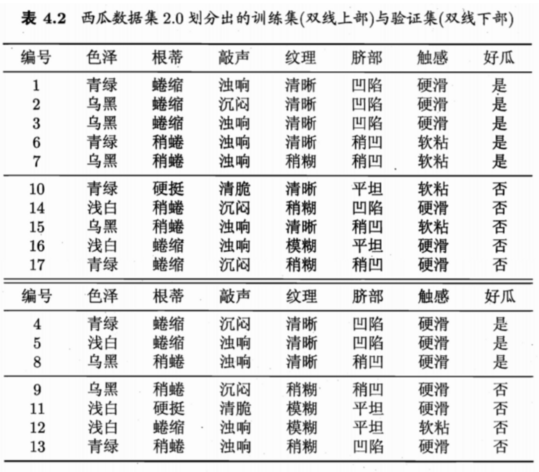

### 5.1 预剪枝
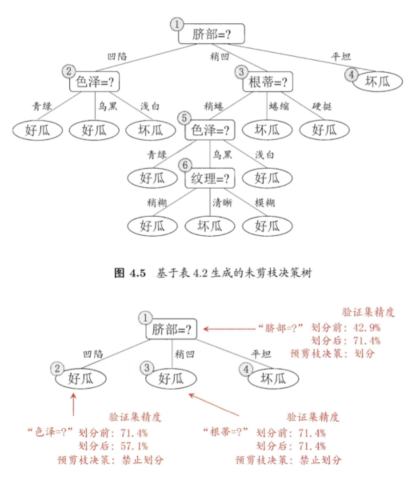

预剪枝的关键在于是否继续进行划分：
- 在上面的西瓜的例子当中，在划分前，我们将其类别标记为训练样例最多的类别“好瓜”。那么在验证集用“脐部”这个结点进行划分，则编号{4,5,8}被划分正确，其划分进度为 3/7*100%=42.9%
- 如果我们使用“脐部”进行划分,那么图中②、③和⑥分别包含编号为{1 ， 2 ， 3 ， 14} 、{6 ， 7 ， 15 ， 17} 和{10 ， 16} 的训练样例,
- 因此这3个结点分别被标记为叶结点“好瓜”、"好瓜"、"坏瓜"（按其训练样例最多类别归属），此时，验证集中编号为{4 ， 5 ， 8 ，11， 12} 的样例被分类正确，验证集精度为5/7 x 100% = 71.4% > 42.9%。于是，用"脐部"进行划分得以确定。

预剪枝使决策树的很多分支都没有展开，不仅降低了过拟合的风险，还显著减少了训练时间和测试时间，但是可能会引起过拟合

### 5.2 后剪枝
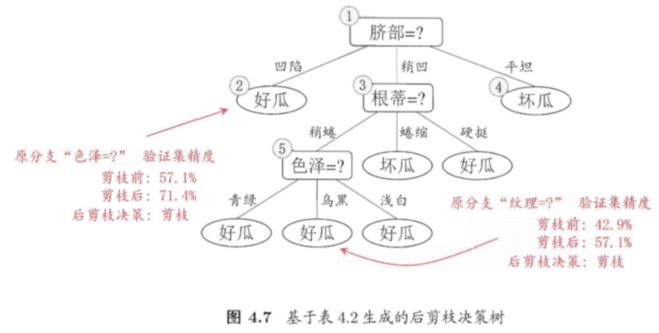

后剪枝通常比预剪枝保留更多的分值，一般情况下，后剪枝欠拟合风险很小，泛化性能优于预剪枝，但其训练时间比未剪枝和预剪枝都要大得多

- 我们基于信息增益算法进行划分决策树，最后在验证集的划分精度为42.9%，我们基于这颗完整的树进行后剪枝
- 我们先考虑结点6 “纹理”，将其替换为叶结点，替换后的结点包含样本{7，15}，因此将其标记为“好瓜”，则此时决策树在验证集的精度提升至57.1%，因此进行剪枝

## 连续与缺失值
### 连续值处理
在C4.5决策树算法当中，使用二分法对连续的数值进行处理：我们可以考察包含n-1个元素的候选划分点集合
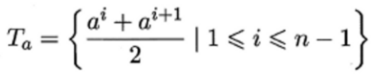


我们将每个区间的中位点作为候选划分点，然后我们使用想离散值属性一样来考察这些划分点，选取最优的划分点进行样本集合的划分，例如：
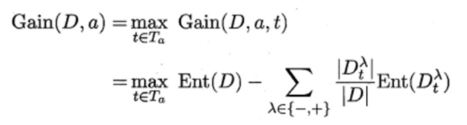


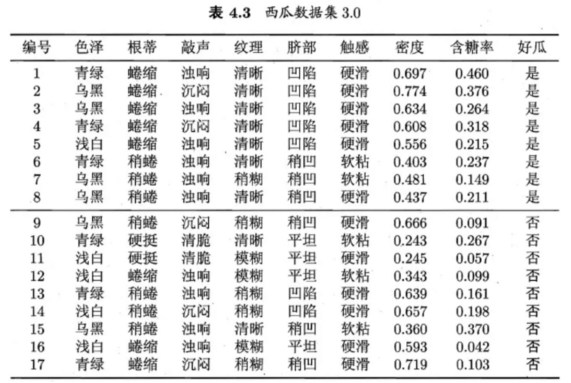

对上图表格当中的例子而言，设置密度为：
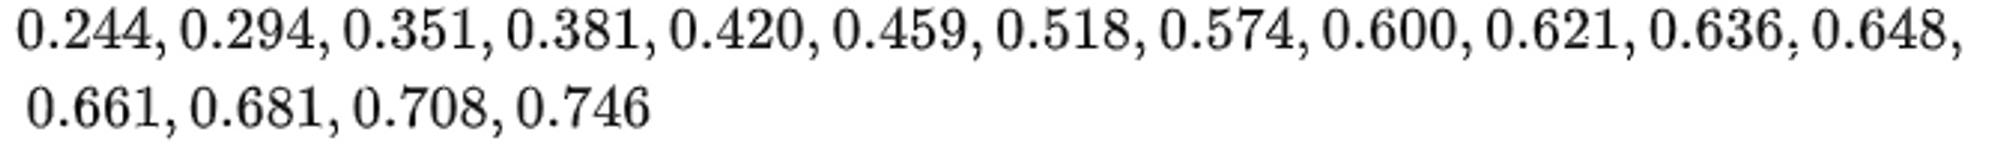

根据Gain的计算公式可以得到属性”密度“的信息增益位0.262，对应于划分点0.381。同时按照之前的离散值的计算方法，计算离散属性的信息增益的值：

Gain(D ，色泽) = 0.109; Gain(D ，根蒂) = 0.143;

Gain(D ，敲声) = 0.141; Gain(D ，纹理) = 0.381;

Gain(D ，脐部) = 0.289; Gain(D ， 触感) = 0.006;

Gain(D ，密度) = 0.262; Gain(D ，含糖率) = 0.349.

可以发现纹理的信息增益是最大的，所以我们选择”纹理“作为根节点作为划分属性，然后每个结点划分过程递归进行，最终生成如图所示的决策树：
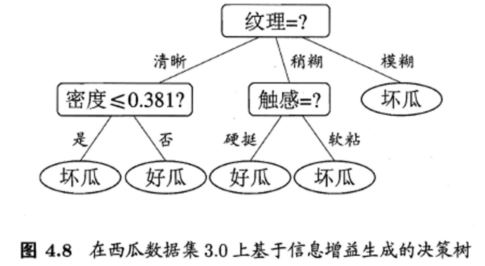

### 缺失值的处理
一些数据由于敏感等原因，部分数据可能会出现缺失的情况，例如下面的情况：
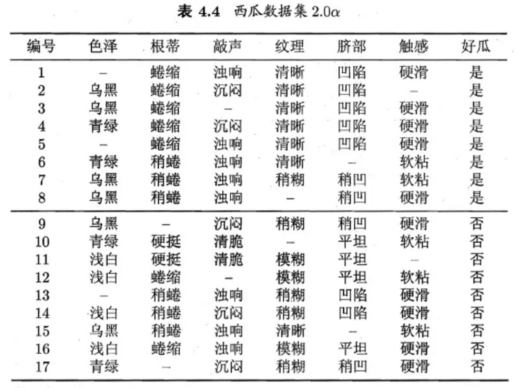

在决策树的C4.5算法当中，我们使用了没有缺失值的样本子集进行树的构建。以上述表格为例子举例，没有缺失值的样例子集包含编号为{2，3，4，6，7，8，9，10，11，12，14，15，16，17}的14个样例（总共有17个样例）。那么相应的信息熵为：
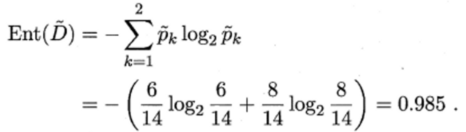

其分别在”色泽“属性上取值为”青绿“，”乌黑“以及”浅白“的样本子集，那么有：
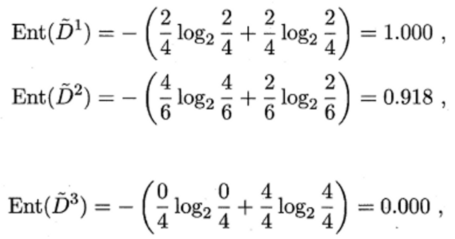

因此在样本子集上，其信息增益为：
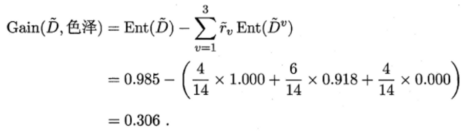

那么在样本集上的”色泽“的信息增益为，要乘以其没有缺失的样例数量除以全部的样例数量：
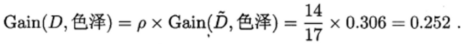

在上述文章提及的变量为，其中每个样本的权重wk为1：
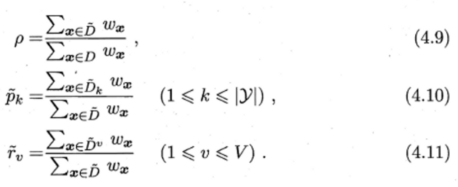

## 决策树算法优缺点
### 优点：

- 1. 决策树具有高度可解释性；
- 2. 需要很少的数据预处理；
- 3. 适用于低延迟应用。

### 劣势：

- 1. 很可能对噪声数据产生过拟合。决策树越深，由噪声产生过拟合的可能性就越大。一种解决方案是对决策树进行剪枝。

### 代码演示-Decision Tree
- 数据集 iris
- sklearn
- 可视化决策树插件 Download：https://graphviz.org/download/
- 决策树插件安装文档：https://blog.csdn.net/u012744245/article/details/103360769

In [ ]:
# -*- coding: utf-8 -*-
 
from sklearn.datasets import load_iris
from sklearn import tree
import pydotplus
import os
#用于划分训练集与测试集
os.environ["PATH"]+=os.pathsep+'C:/Program Files/Graphviz/bin/' #指定路径
from sklearn.model_selection  import train_test_split 
from sklearn.metrics import classification_report 
 
 
#加载数据
iris = load_iris()
#划分训练集与测试集
(training_inputs, testing_inputs, training_classes, testing_classes)=train_test_split(iris.data, iris.target,test_size=0.4, random_state=1)
# 构建模型
clf = tree.DecisionTreeClassifier()
clf = clf.fit(training_inputs, training_classes)
#测试值预测
y_predict = clf.predict(testing_inputs)
#预测值和测试值打分
score = classification_report(testing_classes, y_predict)
print(score)
# 保存模型
with open("iris.dot", 'w') as f:
    f = tree.export_graphviz(clf, out_file=f)
    
# 画图，保存到pdf文件
# 设置图像参数
dot_data = tree.export_graphviz(clf, out_file=None,
                         feature_names=iris.feature_names,
                         class_names=iris.target_names,
                         filled=True, rounded=True,
                         special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)
# 保存图像到pdf文件
graph.write_pdf("irsi.pdf")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      0.95      0.95        21
           2       0.95      0.95      0.95        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



True

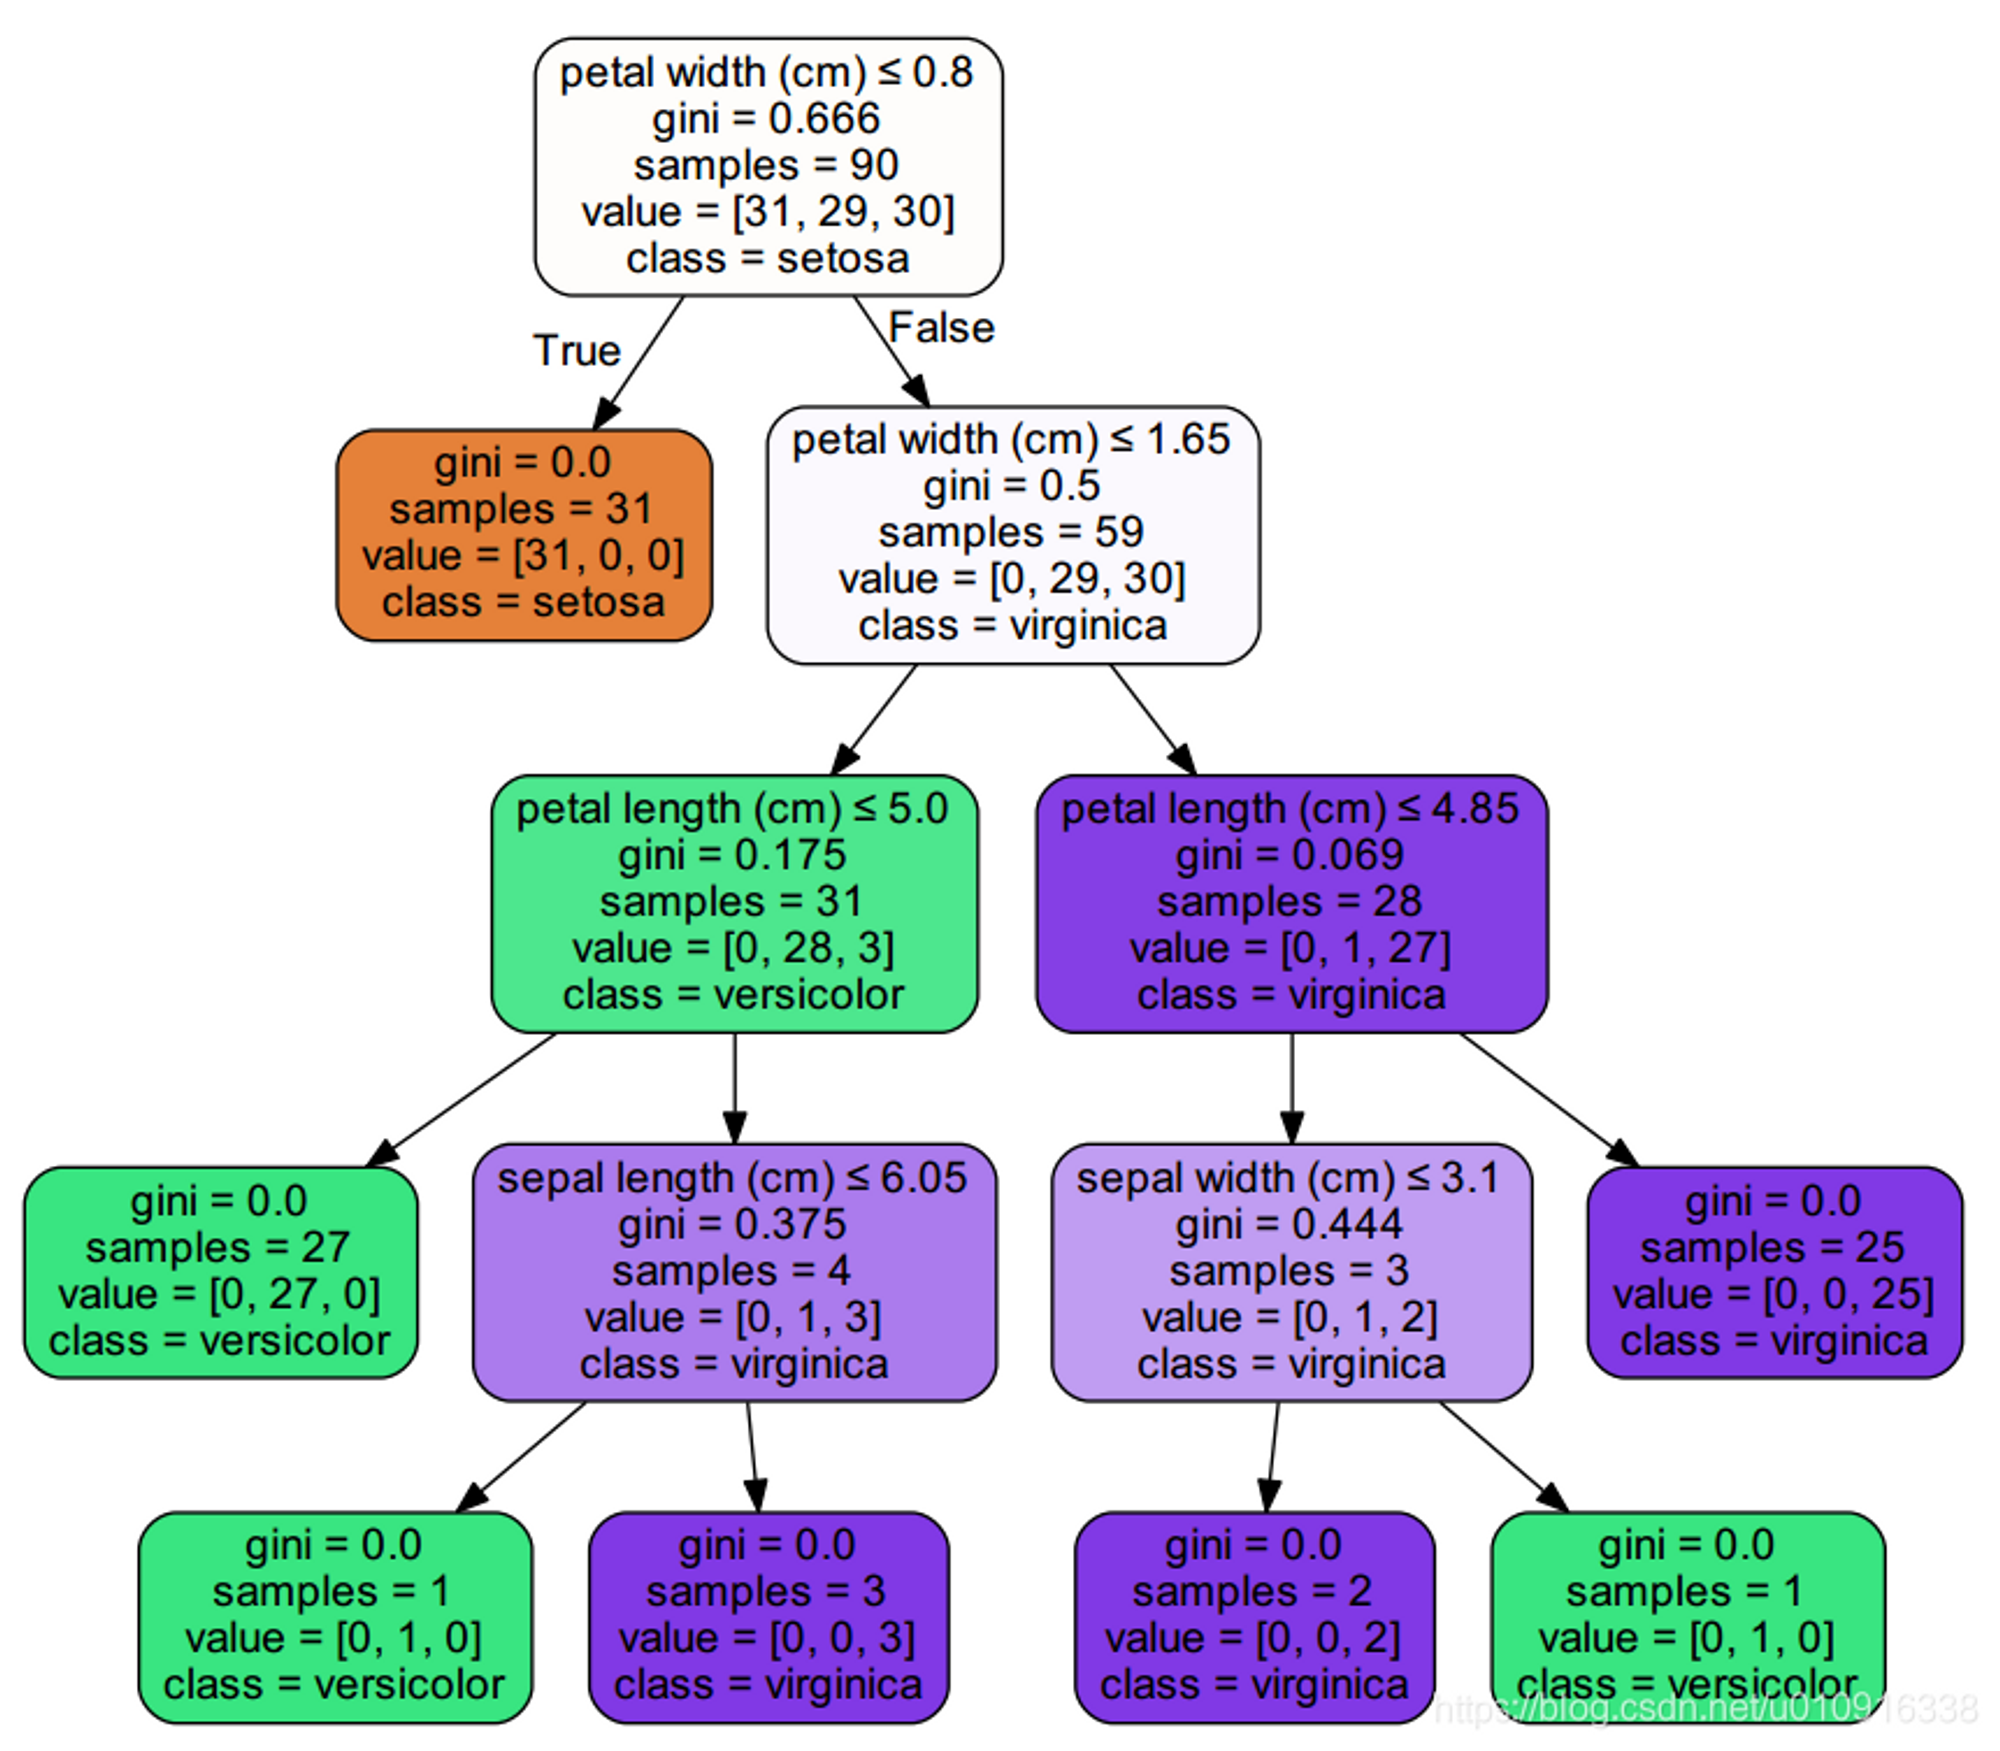